In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
import pyfixest as pf
import warnings
import re
warnings.filterwarnings('ignore')

from pathlib import Path
from IPython.display import Markdown, display

def md(s):
    display(Markdown(s))

OUT_DIR = Path('data/output')

full  = pd.read_csv(OUT_DIR / 'hcris_kff_full.csv')
s2014 = pd.read_csv(OUT_DIR / 'hcris_kff_2014.csv')

for df in [full, s2014]:
    df['year']              = df['year'].astype(int)
    df['expand_ever']       = df['expand_ever'].astype(int)
    df['treat']             = df['treat'].astype(int)
    df['post']              = df['post'].astype(int)
    df['time_to_treat']     = df['time_to_treat'].astype(int)
    df['time_to_treat_bin'] = df['time_to_treat_bin'].astype(int)

s2014_2x2 = s2014[s2014['year'].isin([2012, 2015])].copy()

print('Data loaded.')
print(f'Full panel:    {len(full):,} rows')
print(f'2014 + never:  {len(s2014):,} rows')

Data loaded.
Full panel:    35,709 rows
2014 + never:  25,391 rows


In [2]:
# Question 1

q1_tab = (
    full
    .groupby('year')['uncomp_care_m']
    .agg(Mean='mean', SD='std', N='count')
    .round(2)
    .reset_index()
    .rename(columns={'year': 'Year'})
)

display(
    q1_tab.style
    .set_caption('Mean Hospital Uncompensated Care ($mm) by Year')
    .format({'Mean': '{:.2f}', 'SD': '{:.2f}', 'N': '{:,.0f}'})
    .hide(axis='index')
)

Year,Mean,SD,N
2011,6.24,18.42,"2,920"
2012,7.76,35.68,"4,924"
2013,8.25,52.93,"4,785"
2014,7.11,24.10,"4,780"
2015,5.98,18.58,"4,747"
2016,8.46,99.52,"4,733"
2017,9.15,33.48,"4,441"
2018,8.81,22.72,"4,379"


In [3]:
md(
    "Uncompensated care rose from 6.24mm per hospital in 2011 to 8.25mm in 2013. "
    "It then fell to 7.11mm in 2014 and further to 5.98mm in 2015, which is consistent "
    "with the ACA's Medicaid expansion taking effect. Newly insured patients generated "
    "reimbursable claims rather than uncompensated care. However, the trend does not "
    "sustain a clean decline. The mean rose sharply in 2016 and peaked at 9.15mm in 2017. "
    "The 2016 figure carries an unusually large standard deviation of 99.52mm, indicating "
    "a small number of hospitals with extreme values are pulling the mean up rather than a "
    "genuine system-wide reversal."
)

Uncompensated care rose from 6.24mm per hospital in 2011 to 8.25mm in 2013. It then fell to 7.11mm in 2014 and further to 5.98mm in 2015, which is consistent with the ACA's Medicaid expansion taking effect. Newly insured patients generated reimbursable claims rather than uncompensated care. However, the trend does not sustain a clean decline. The mean rose sharply in 2016 and peaked at 9.15mm in 2017. The 2016 figure carries an unusually large standard deviation of 99.52mm, indicating a small number of hospitals with extreme values are pulling the mean up rather than a genuine system-wide reversal.

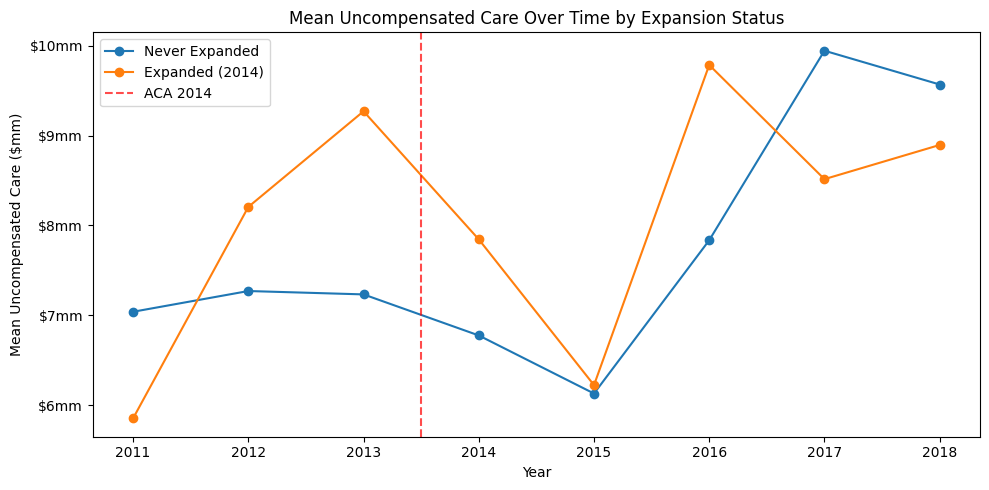

In [4]:
# Question 2

q2_dat = (
    s2014
    .groupby(['expand_ever', 'year'])['uncomp_care_m']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
for val, grp in q2_dat.groupby('expand_ever'):
    label = 'Expanded (2014)' if val == 1 else 'Never Expanded'
    ax.plot(grp['year'], grp['uncomp_care_m'], marker='o', label=label)
ax.axvline(2013.5, color='red', linestyle='--', alpha=0.7, label='ACA 2014')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Uncompensated Care ($mm)')
ax.set_title('Mean Uncompensated Care Over Time by Expansion Status')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}mm'))
plt.tight_layout()
plt.show()

In [5]:
md(
    "The graph does suggest a treatment effect. Before 2014 the two groups tracked each "
    "other fairly closely, with expanders averaged 9.27mm and never-expanders 7.23mm in 2013. "
    "After expansion, both groups declined, but expanding states fell more sharply, reaching "
    "6.22mm by 2015 compared to 6.13mm for never-expanders. The gap opening up right at "
    "2014 is consistent with Medicaid expansion converting previously uninsured patients "
    "into covered ones, reducing the care hospitals had to absorb for free."
)

The graph does suggest a treatment effect. Before 2014 the two groups tracked each other fairly closely, with expanders averaged 9.27mm and never-expanders 7.23mm in 2013. After expansion, both groups declined, but expanding states fell more sharply, reaching 6.22mm by 2015 compared to 6.13mm for never-expanders. The gap opening up right at 2014 is consistent with Medicaid expansion converting previously uninsured patients into covered ones, reducing the care hospitals had to absorb for free.

In [6]:
# Question 3

q3_tab = (
    s2014_2x2
    .groupby(['expand_ever', 'year'])['uncomp_care_m']
    .mean()
    .unstack('year')
    .rename(columns={2012: 'Pre (2012)', 2015: 'Post (2015)'})
)
q3_tab.index = q3_tab.index.map({0: 'Never Expanded', 1: 'Expanded (2014)'})
q3_tab['Difference'] = q3_tab['Post (2015)'] - q3_tab['Pre (2012)']
q3_tab = q3_tab.round(2)

dd_est = (
    q3_tab.loc['Expanded (2014)', 'Difference'] -
    q3_tab.loc['Never Expanded',  'Difference']
)

display(
    q3_tab.style
    .set_caption(f'2x2 DD Table of Mean Uncompensated Care ($mm) — DD Estimate: ${dd_est:.2f}mm')
    .format('{:.2f}')
)

year,Pre (2012),Post (2015),Difference
expand_ever,,,
Never Expanded,7.27,6.13,-1.14
Expanded (2014),8.21,6.22,-1.98


In [7]:
# Question 4

md(
    "Several forces were at work during this period. The most direct is Medicaid expansion "
    "itself which covered adults up to 138% of the federal poverty level. This means that "
    "hospitals could bill for care they previously wrote off entirely. But the ACA's "
    "insurance exchanges were also pulling in uninsured people in non-expansion states, "
    "which partly explains why never-expanders also saw declines. The broader economic "
    "recovery from the 2008 recession reduced the share of patients unable to pay their "
    "bills. Also, S-10 reporting standards shifted around 2012-2013, so some of the "
    "measured change reflects accounting practices rather than actual care delivered. "
    "Taken together, we expect expansion to reduce uncompensated care specifically because "
    "insured patients generate reimbursable claims. Hospitals get paid instead of "
    "absorbing the cost."
)

Several forces were at work during this period. The most direct is Medicaid expansion itself which covered adults up to 138% of the federal poverty level. This means that hospitals could bill for care they previously wrote off entirely. But the ACA's insurance exchanges were also pulling in uninsured people in non-expansion states, which partly explains why never-expanders also saw declines. The broader economic recovery from the 2008 recession reduced the share of patients unable to pay their bills. Also, S-10 reporting standards shifted around 2012-2013, so some of the measured change reflects accounting practices rather than actual care delivered. Taken together, we expect expansion to reduce uncompensated care specifically because insured patients generate reimbursable claims. Hospitals get paid instead of absorbing the cost.

In [8]:
# Question 5

q5 = smf.ols(
    'uncomp_care_m ~ post + expand_ever + treat',
    data=s2014
).fit()

q5_coef = q5.params['treat']
q5_se   = q5.bse['treat']
q5_pval = q5.pvalues['treat']
q5_n    = int(q5.nobs)

print(q5.summary().tables[1])
print(f'\ntreat coef: {q5_coef:.3f}  SE: {q5_se:.3f}  p: {q5_pval:.4f}  N: {q5_n:,}')

                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       7.1997      1.105      6.516      0.000       5.034       9.365
post            0.8088      1.370      0.590      0.555      -1.876       3.494
expand_ever     0.8813      1.289      0.683      0.494      -1.646       3.409
treat          -0.6495      1.599     -0.406      0.685      -3.784       2.485

treat coef: -0.649  SE: 1.599  p: 0.6846  N: 25,391


In [9]:
# Question 6

q6 = pf.feols(
    'uncomp_care_m ~ treat | provider_number + year',
    data=s2014,
    vcov={'CRV1': 'state'}
)

print(q6.summary())

q6_coef = q6.coef()['treat']
q6_se   = q6.se()['treat']
q6_pval = q6.pvalue()['treat']
q6_n    = int(q6._N)

md(
    "Adding hospital and year fixed effects changes the estimate noticeably. The simple "
    "DD (Q5) gave -0.649mm (SE 1.599, p=0.685), while the TWFE estimate is -1.268mm "
    "(SE 1.884, p=0.505) on 25,197 observations. Hospital fixed effects absorb permanent "
    "differences across hospitals (size, teaching status, location) that were biasing "
    "the simple DD upward. Year fixed effects remove common trends affecting all hospitals "
    "regardless of expansion status. Neither estimate is statistically significant, but "
    "both are negative and point in the expected direction. The TWFE estimate is larger "
    "in magnitude than the simple DD, suggesting OLS was understating the effect of expansion."
)

###

Estimation:  OLS
Dep. var.: uncomp_care_m, Fixed effects: provider_number+year
Inference:  CRV1
Observations:  25197

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| treat         |     -1.268 |        1.884 |    -0.673 |      0.505 | -5.093 |   2.556 |
---
RMSE: 45.067 R2: 0.301 R2 Within: 0.0 
None


Adding hospital and year fixed effects changes the estimate noticeably. The simple DD (Q5) gave -0.649mm (SE 1.599, p=0.685), while the TWFE estimate is -1.268mm (SE 1.884, p=0.505) on 25,197 observations. Hospital fixed effects absorb permanent differences across hospitals (size, teaching status, location) that were biasing the simple DD upward. Year fixed effects remove common trends affecting all hospitals regardless of expansion status. Neither estimate is statistically significant, but both are negative and point in the expected direction. The TWFE estimate is larger in magnitude than the simple DD, suggesting OLS was understating the effect of expansion.

In [10]:
# Question 7

q7 = pf.feols(
    'uncomp_care_m ~ treat | provider_number + year',
    data=full,
    vcov={'CRV1': 'state'}
)

print(q7.summary())

q7_coef = q7.coef()['treat']
q7_se   = q7.se()['treat']
q7_pval = q7.pvalue()['treat']
q7_n    = int(q7._N)

md(
    "Including all states shifts the estimate from -1.268mm to -0.643mm, moving it "
    "closer to zero. This can reflect a certain problem with TWFE under staggered adoption. "
    "When states expand at different times, already-treated states get used as implicit "
    "controls for later-treated ones. If treatment effects differ across expansion cohorts "
    "or evolve over time, this contaminates the estimate. The fact that the coefficient "
    "shifts when late-expanders are added is a signal that those dynamics are present here."
)

###

Estimation:  OLS
Dep. var.: uncomp_care_m, Fixed effects: provider_number+year
Inference:  CRV1
Observations:  35462

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| treat         |     -0.643 |        1.321 |    -0.487 |      0.629 | -3.297 |   2.011 |
---
RMSE: 38.58 R2: 0.334 R2 Within: 0.0 
None


Including all states shifts the estimate from -1.268mm to -0.643mm, moving it closer to zero. This can reflect a certain problem with TWFE under staggered adoption. When states expand at different times, already-treated states get used as implicit controls for later-treated ones. If treatment effects differ across expansion cohorts or evolve over time, this contaminates the estimate. The fact that the coefficient shifts when late-expanders are added is a signal that those dynamics are present here.

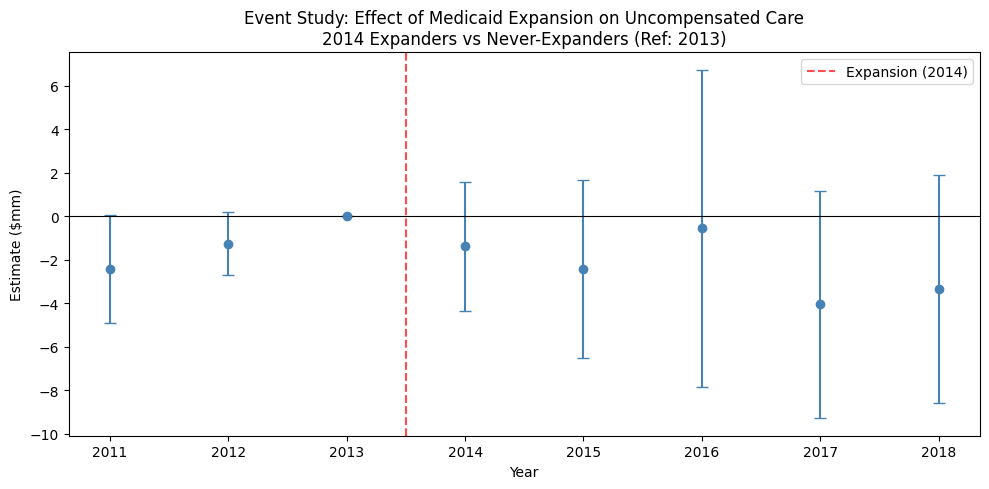

In [11]:
# Question 8

q8 = pf.feols(
    'uncomp_care_m ~ i(year, expand_ever, ref=2013) | provider_number + year',
    data=s2014,
    vcov={'CRV1': 'state'}
)

q8_coefs = q8.coef()
q8_ses   = q8.se()

years_plot, ests, cis_low, cis_high = [], [], [], []
for key in q8_coefs.index:
    m = re.search(r'\[(\d+)\]:expand_ever', key)
    if m:
        yr  = int(m.group(1))
        est = float(q8_coefs[key])
        se  = float(q8_ses[key])
        years_plot.append(yr)
        ests.append(est)
        cis_low.append(est - 1.96 * se)
        cis_high.append(est + 1.96 * se)

years_plot.append(2013); ests.append(0); cis_low.append(0); cis_high.append(0)
sorted_data = sorted(zip(years_plot, ests, cis_low, cis_high))
years_plot, ests, cis_low, cis_high = zip(*sorted_data)
ests     = np.array(ests)
cis_low  = np.array(cis_low)
cis_high = np.array(cis_high)

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    years_plot, ests,
    yerr=[ests - cis_low, cis_high - ests],
    fmt='o', color='steelblue', capsize=4, linewidth=1.5
)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(2013.5, color='red', linestyle='--', alpha=0.7, label='Expansion (2014)')
ax.set_xlabel('Year')
ax.set_ylabel('Estimate ($mm)')
ax.set_title(
    'Event Study: Effect of Medicaid Expansion on Uncompensated Care\n'
    '2014 Expanders vs Never-Expanders (Ref: 2013)'
)
ax.set_xticks(list(years_plot))
ax.legend()
plt.tight_layout()
plt.show()

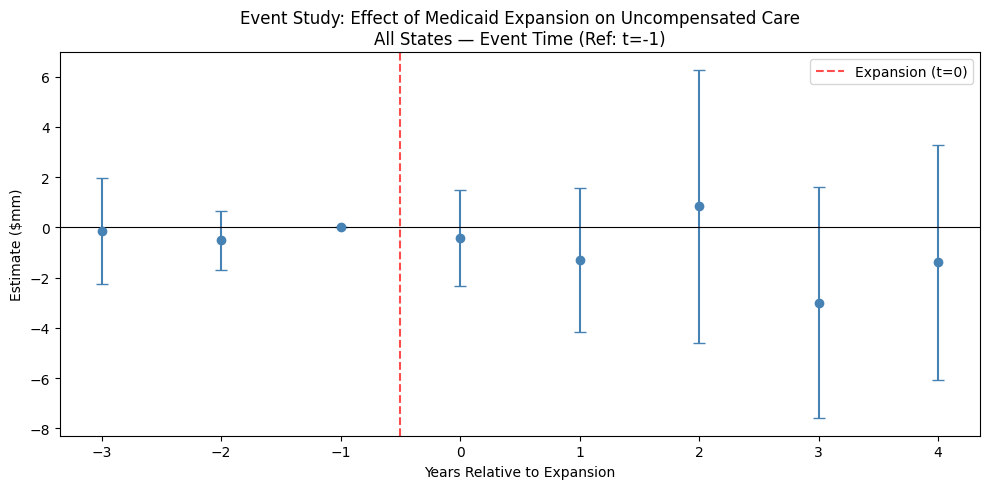

In [12]:
# Question 9

q9 = pf.feols(
    'uncomp_care_m ~ i(time_to_treat_bin, expand_ever, ref=-1) | provider_number + year',
    data=full,
    vcov={'CRV1': 'state'}
)

q9_coefs = q9.coef()
q9_ses   = q9.se()

times_plot, ests9, cis_low9, cis_high9 = [], [], [], []
for key in q9_coefs.index:
    m = re.search(r'\[(-?\d+)\]:expand_ever', key)
    if m:
        t   = int(m.group(1))
        est = float(q9_coefs[key])
        se  = float(q9_ses[key])
        times_plot.append(t)
        ests9.append(est)
        cis_low9.append(est - 1.96 * se)
        cis_high9.append(est + 1.96 * se)

times_plot.append(-1); ests9.append(0); cis_low9.append(0); cis_high9.append(0)
sorted_data9 = sorted(zip(times_plot, ests9, cis_low9, cis_high9))
times_plot, ests9, cis_low9, cis_high9 = zip(*sorted_data9)
ests9     = np.array(ests9)
cis_low9  = np.array(cis_low9)
cis_high9 = np.array(cis_high9)

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    times_plot, ests9,
    yerr=[ests9 - cis_low9, cis_high9 - ests9],
    fmt='o', color='steelblue', capsize=4, linewidth=1.5
)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(-0.5, color='red', linestyle='--', alpha=0.7, label='Expansion (t=0)')
ax.set_xlabel('Years Relative to Expansion')
ax.set_ylabel('Estimate ($mm)')
ax.set_title(
    'Event Study: Effect of Medicaid Expansion on Uncompensated Care\n'
    'All States — Event Time (Ref: t=-1)'
)
ax.set_xticks(list(times_plot))
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# Question 10

md(
    "Across Questions 5 through 9, the results consistently point toward Medicaid expansion "
    "reducing uncompensated care, though none of the estimates reach statistical "
    "significance. The simple DD (Q5) gave -0.649mm, TWFE on the 2014 sample (Q6) gave "
    "-1.268mm, and adding all states (Q7) produced -0.643mm — all negative and in the "
    "expected direction.\n\n"
    "The event study in Q8 raises some concern about parallel trends. The pre-period "
    "coefficients for 2011 (-2.440mm, SE 1.266) and 2012 (-1.250mm) are not close to "
    "zero, suggesting expanding and non-expanding states may have been on somewhat "
    "different trajectories before 2014. If that pre-existing divergence is real, our DD "
    "estimates partly capture it rather than the effect of expansion alone. Post-expansion, "
    "the coefficient for 2015 is -2.414mm and remains negative through the end of the "
    "sample, consistent with a persistent reduction in uncompensated care, though the wide "
    "confidence intervals make it difficult to pin down the magnitude with precision.\n\n"
    "The core limitation of TWFE with staggered adoption is that it uses already-treated "
    "states as controls for later-treated ones. If early and late expanders experienced "
    "different effect sizes, those comparisons inject bias and can even produce "
    "negative weights on some underlying 2x2 DDs. There are other alternatives that can "
    "estimate cohort-specific effects before aggregating, which avoids this problem by "
    "never using treated units as controls."
)

Across Questions 5 through 9, the results consistently point toward Medicaid expansion reducing uncompensated care, though none of the estimates reach statistical significance. The simple DD (Q5) gave -0.649mm, TWFE on the 2014 sample (Q6) gave -1.268mm, and adding all states (Q7) produced -0.643mm — all negative and in the expected direction.

The event study in Q8 raises some concern about parallel trends. The pre-period coefficients for 2011 (-2.440mm, SE 1.266) and 2012 (-1.250mm) are not close to zero, suggesting expanding and non-expanding states may have been on somewhat different trajectories before 2014. If that pre-existing divergence is real, our DD estimates partly capture it rather than the effect of expansion alone. Post-expansion, the coefficient for 2015 is -2.414mm and remains negative through the end of the sample, consistent with a persistent reduction in uncompensated care, though the wide confidence intervals make it difficult to pin down the magnitude with precision.

The core limitation of TWFE with staggered adoption is that it uses already-treated states as controls for later-treated ones. If early and late expanders experienced different effect sizes, those comparisons inject bias and can even produce negative weights on some underlying 2x2 DDs. There are other alternatives that can estimate cohort-specific effects before aggregating, which avoids this problem by never using treated units as controls.